#### Import necessary libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

#### User defined functions. Must  runt his cell before they can be used.

In [ ]:
# --- Define the cosine model ---
def cosine_model(t, A, f, phi, offset):
    return A * np.cos(2 * np.pi * f * t + phi) + offset

# Define the beat model (two coupled oscillators) ---
def beat_func(t, A1, A2, f1, f2, phi1, phi2, offset):
    return A1 * np.cos(2 * np.pi * f1 * t + phi1) + \
           A2 * np.cos(2 * np.pi * f2 * t + phi2) + offset

# Plotting the x vs t graph
def plotter(t,y,start,end,title):
    mask = (t >= start) & (t <= end)
    t_zoom = t[mask]
    y_zoom = y[mask]

    plt.figure(figsize=(10, 5))
    plt.plot(t_zoom, y_zoom, label="Data", lw=1)
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.title(title)
    plt.legend()
    plt.show()
    return t_zoom,y_zoom
    
    
# fit cosine date
def fit_cosine_data(t,y):
# --- Step 1: Provide initial parameter guesses ---
    A0 = (np.max(y) - np.min(y)) / 2
    offset0 = np.mean(y)
    
    # Rough frequency estimate using FFT
    yf = np.fft.rfft(y - offset0)
    xf = np.fft.rfftfreq(len(t), t[1] - t[0])
    omega0 = xf[np.argmax(np.abs(yf[1:])) + 1]  # avoid DC component
    phi0 = 0.0

    initial_guess = [A0, omega0, phi0, offset0]

    # Fit the data ---
    popt, pcov = curve_fit(cosine_model, t, y, p0=initial_guess)

    # Compute fitted values ---
    fit_y = cosine_model(t, *popt)
    
    return popt, pcov, fit_y

# Perform fft
def analyze_fft(t, y, title,fmin=0.25, fmax=0.9, peak_threshold=0.2, plot=True):
    """
    Performs FFT analysis on a time-domain signal and plots the amplitude spectrum.

    Parameters
    ----------
    t : array-like
        Time array.
    y : array-like
        Signal array corresponding to t.
    fmin : float, optional
        Minimum frequency limit for the plot (default = 0.25 Hz).
    fmax : float, optional
        Maximum frequency limit for the plot (default = 0.9 Hz).
    peak_threshold : float, optional
        Fraction of the maximum amplitude used for peak detection (default = 0.2).
    plot : bool, optional
        If True, displays the FFT amplitude spectrum.

    Returns
    -------
    freq : ndarray
        Frequency axis (positive frequencies only).
    amplitude : ndarray
        Normalized FFT amplitude spectrum.
    dominant_freqs : ndarray
        Detected dominant frequencies in Hz.
    """
    # --- Step 1: Compute sampling parameters ---
    dt = t[1] - t[0]           # time step
    fs = 1 / dt                # sampling frequency
    N = len(y)                 # number of data points

    # --- Step 2: Perform FFT ---
    Y = np.fft.fft(y - np.mean(y))   # remove DC offset
    freq = np.fft.fftfreq(N, d=dt)

    # Only positive half
    mask = freq > 0
    freq = freq[mask]
    amplitude = np.abs(Y[mask]) * 2 / N

    # --- Step 3: Find dominant peaks ---
    peaks, _ = find_peaks(amplitude, height=np.max(amplitude) * peak_threshold)
    dominant_freqs = freq[peaks]

    # --- Step 4: Plot if requested ---
    if plot:
        plt.figure(figsize=(10, 5))
        plt.plot(freq, amplitude, 'r-', linewidth=1.5)
        plt.xlim([fmin, fmax])
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Amplitude (normalized)")
        plt.title("FFT Spectrum of   " + title +"Oscillator")
        plt.grid(True)
        plt.show()

    # --- Step 5: Print dominant frequencies ---
    print("Dominant frequencies (Hz):", np.round(dominant_freqs, 4))

    return freq, amplitude, dominant_freqs

# plot the data and the superimpose the fitted data
def fit_plotter(t,y,yfit):
    plt.figure(figsize=(10, 5))
    plt.plot(t, y, 'k.', label="Data (25–75 range)", markersize=4)
    plt.plot(t, yfit, 'r-', label="Fitted curve", linewidth=2)
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.title("Coupled Oscillator Fit (Zoomed: 25–75)")
    plt.legend()
    plt.show()


#### Load the in-phase,ou-phase and beats data. Also visulize and select the usable part of the data.

In [ ]:
# Load the in_phase data --- and plot it

data_inphase = pd.read_csv("in_1.csv")

data_inphase["x0000"] = pd.to_numeric(data_inphase["x0000"], errors='coerce')
data_inphase["y0000"] = pd.to_numeric(data_inphase["y0000"], errors='coerce')
    
t_inphase = data_inphase["x0000"].values
y_inphase = data_inphase["y0000"].values
    
print("Minimum t:", np.min(t_inphase))
print("Maximum t:", np.max(t_inphase))

plotter(t_inphase,y_inphase,0,np.max(t_inphase),"In-phase")

Minimum t: 0.000
Maximum t: …


TypeError: '>=' not supported between instances of 'str' and 'int'

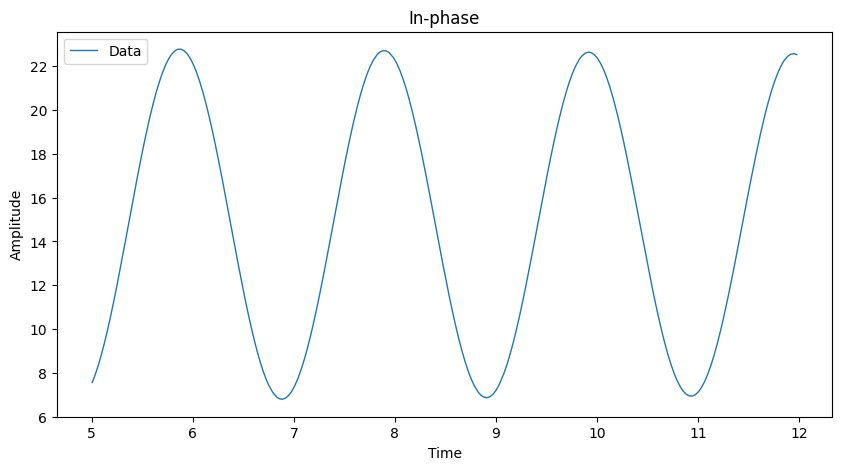

In [ ]:
# Select usable data range - specify start and end times
ti,yi = plotter(t_inphase,y_inphase,5,12,"In-phase")

Minimum t: 0.0
Maximum t: 60.0248272419


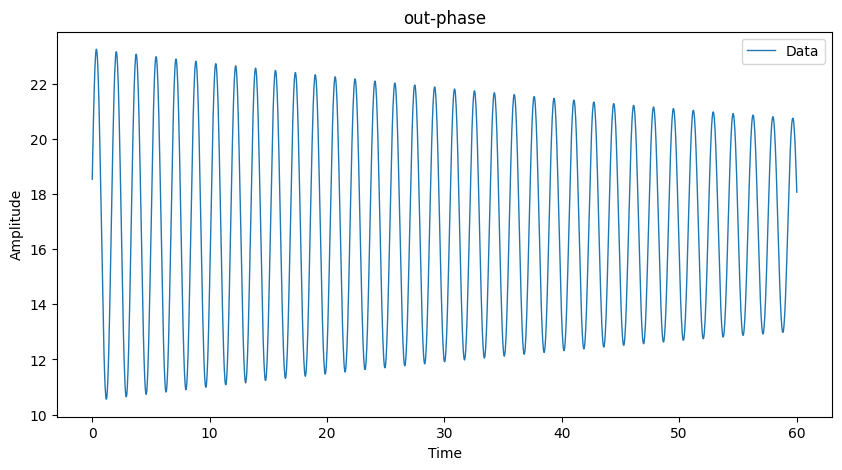

(array([0.00000000e+00, 3.08988094e-02, 6.16862774e-02, ...,
        5.99627481e+01, 5.99941757e+01, 6.00248272e+01], shape=(1918,)),
 array([18.54172214, 19.2359018 , 19.89657988, ..., 18.8804058 ,
        18.48181425, 18.07235492], shape=(1918,)))

In [ ]:
# Load the out_phase data --- and plot it 
data_outphase = pd.read_csv("out_1.csv")
t_outphase = data_outphase["x0001"].values
y_outphase = data_outphase["y0001"].values

print("Minimum t:", np.min(t_outphase))
print("Maximum t:", np.max(t_outphase))

plotter(t_outphase,y_outphase,0,np.max(t_outphase),"out-phase")

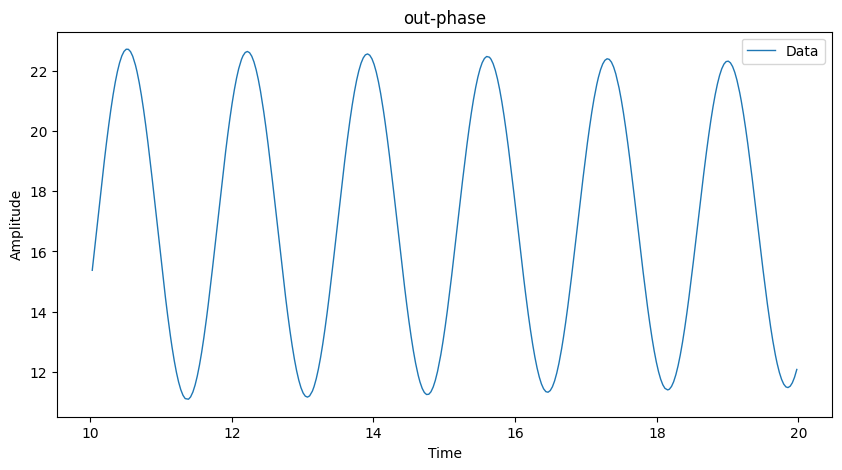

In [ ]:
# Select usable data range - specify start and end times
to,yo = plotter(t_outphase,y_outphase,10,20,"out-phase")

Minimum t: 0.0
Maximum t: 59.9619483948


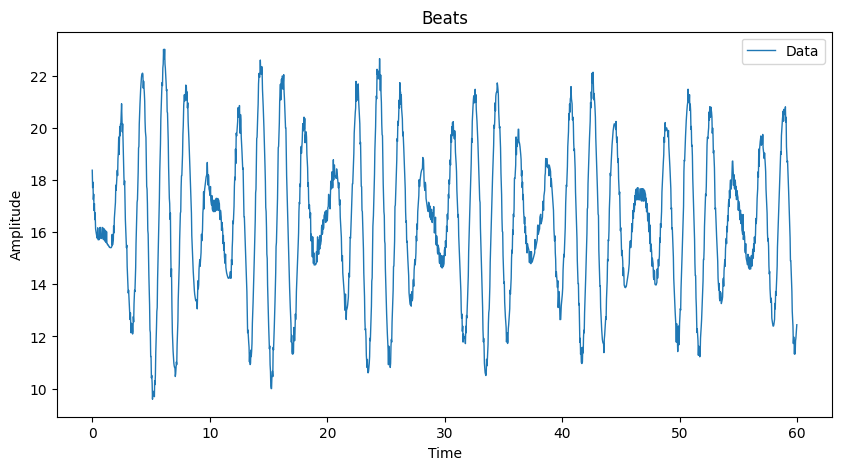

(array([0.00000000e+00, 3.11741829e-02, 6.15322590e-02, ...,
        5.98841949e+01, 5.99151971e+01, 5.99619484e+01], shape=(1916,)),
 array([18.377     , 17.71107813, 17.91853125, ..., 11.936125  ,
        12.138     , 12.45090625], shape=(1916,)))

In [ ]:
# Load the beats data --- and plot it
data_beats = pd.read_csv("b_2.csv")
t_beats = data_beats["x0000"].values
y_beats = data_beats["y0000"].values

print("Minimum t:", np.min(t_beats))
print("Maximum t:", np.max(t_beats))

plotter(t_beats,y_beats,0,np.max(t_beats),"Beats")

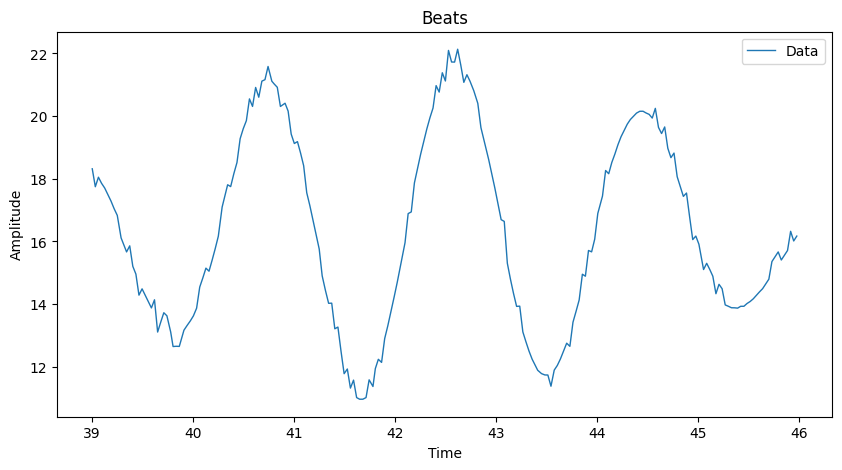

In [ ]:
# Select usable data range - specify start and end times
tb,yb = plotter(t_beats,y_beats,39,46,"Beats")

#### Perform fft of all 3 data

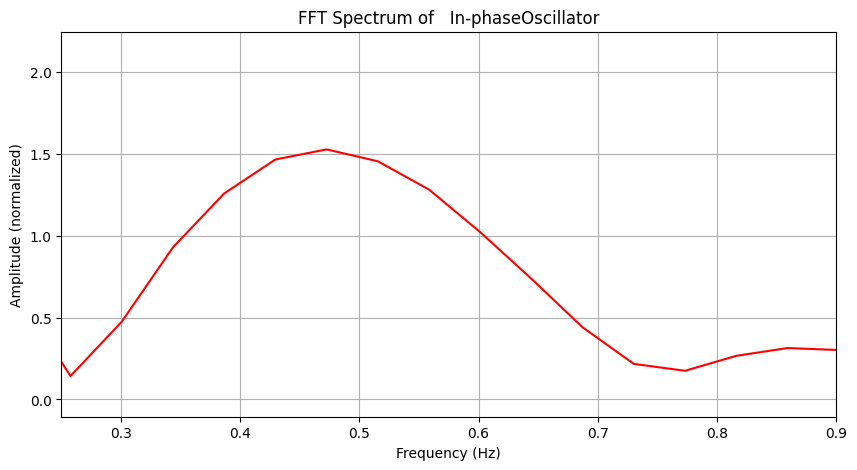

Dominant frequencies (Hz): [0.4725 8.0753]


In [ ]:
# fft of in-phase
freq, amp, peaks = analyze_fft(t_inphase, y_inphase,'In-phase')



#store the frequency value in a dataframe
df_freq = pd.DataFrame(columns=["FFT Frequency"])
df_freq.loc["in-phase", "FFT Frequency"] = peaks[0]




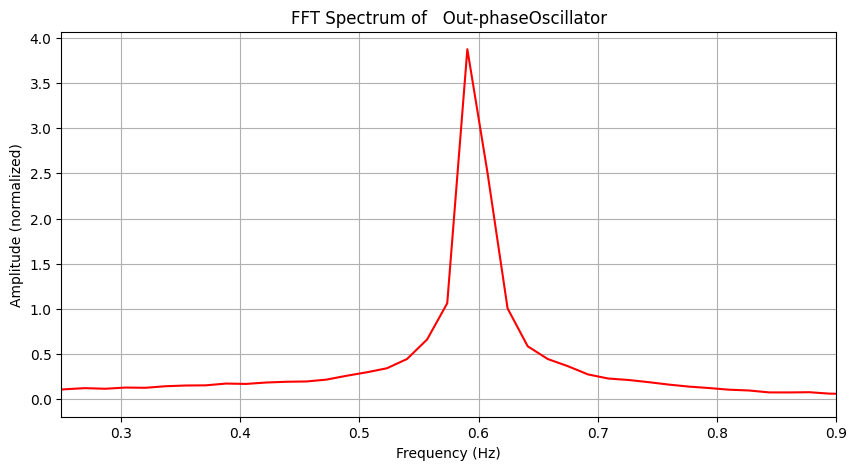

Dominant frequencies (Hz): [0.5906]


,FFT Frequency
in-phase,0.501562
out-phase,0.590579


In [ ]:
# fft of out-phase
freq, amp, peaks = analyze_fft(t_outphase, y_outphase, "Out-phase")
df_freq.loc["out-phase", "FFT Frequency"] = peaks[0]
df_freq

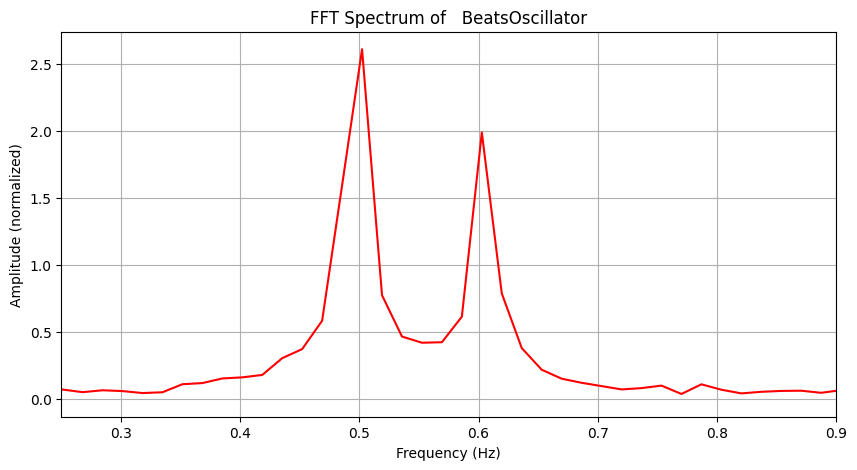

Dominant frequencies (Hz): [0.5023 0.6027]


In [ ]:
# fft of beats
freq3, amp, peaks = analyze_fft(t_beats, y_beats,'Beats')
#df_freq.loc["Beats-1", "FFT Frequency"] = peaks[0]
#df_freq.loc["Beats -2", "FFT Frequency"] = peaks[1]
#df_freq

[-7.91447908  0.49380739 -2.50586267 14.77081404]


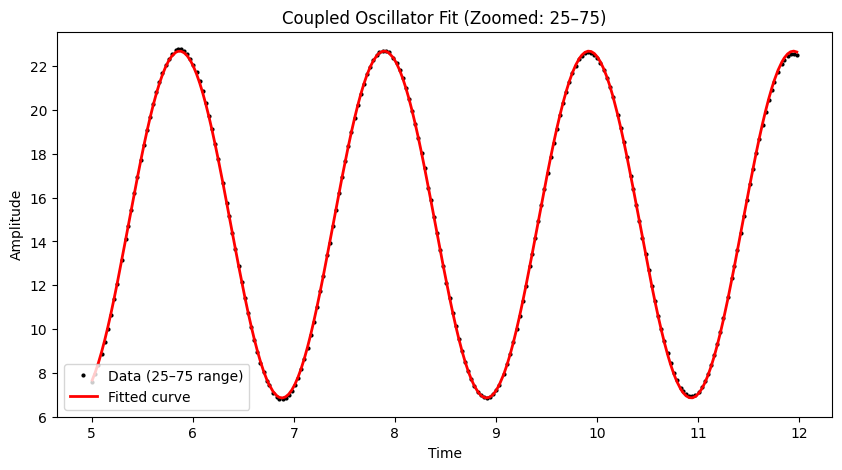

In [ ]:
# Fit inphase data
popt, pcov, fit_y = fit_cosine_data(ti,yi)
print(popt)
fit_plotter(ti, yi, fit_y)

#store the frequency value in a dataframe
fit_freq = pd.DataFrame(columns=["Fit Frequency"])
fit_freq.loc["in-phase", "Fit Frequency"] = popt[1]

[-5.63359927  0.58984495  1.83837011 16.89272112]


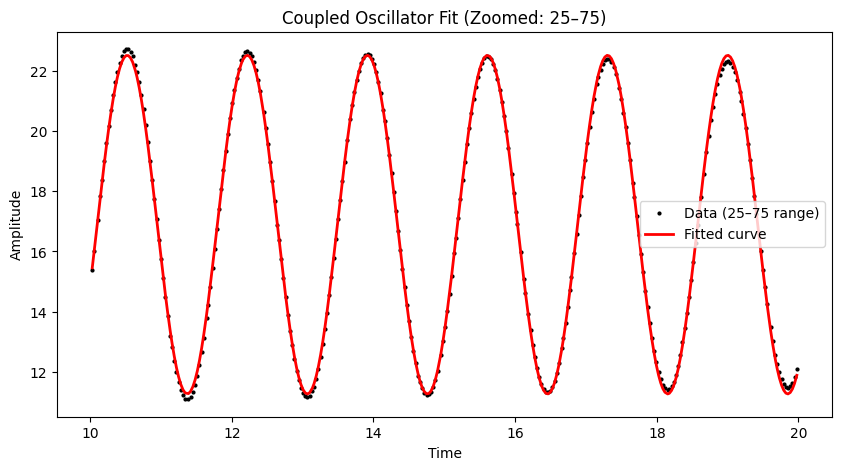

,Fit Frequency
in-phase,0.493807
out-phase,0.589845


In [ ]:
# fit outphase data
popt, pcov, fit_y = fit_cosine_data(to,yo)
print(popt)
fit_plotter(to,yo,fit_y)

fit_freq.loc["out-phase", "Fit Frequency"] = popt[1]
fit_freq

In [ ]:
df_combined = pd.concat([df_freq, fit_freq], axis=1)
df_combined = df_combined.apply(pd.to_numeric, errors='ignore')
df_combined = df_combined.round(2) 
df_combined

C:\Users\kctho\AppData\Local\Temp\ipykernel_12612\2000280340.py:2: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_combined = df_combined.apply(pd.to_numeric, errors='ignore')


,FFT Frequency,Fit Frequency
in-phase,0.50,0.49
out-phase,0.59,0.59


Fitted parameters:
A1=-1.8855, A2=3.4534, f1=0.6158, f2=0.4974, phi1=-4.4263, phi2=5.0247, offset=16.4741


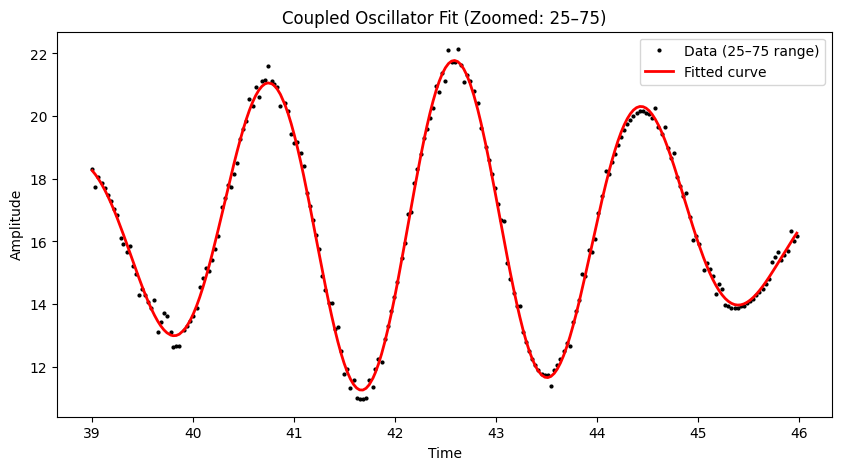

In [ ]:
# Fit beats data
guess = [4, 3, 0.6, 0.49,  0.55, 2.45, np.mean(yb)] # [A1,A2,f1,f2,phi,phi2,offset]



# --- Step 4: Fit the model ---
params, cov = curve_fit(beat_func, tb, yb, p0=guess, maxfev=20000)


# Extract fitted parameters
A1, A2, f1, f2, phi1, phi2, offset = params
print(f"Fitted parameters:\nA1={A1:.4f}, A2={A2:.4f}, f1={f1:.4f}, f2={f2:.4f}, "
      f"phi1={phi1:.4f}, phi2={phi2:.4f}, offset={offset:.4f}")

# --- Step 5: Generate fitted data ---
y_fit = beat_func(tb, *params)

fit_plotter(tb,yb,y_fit)

In [ ]:
df_combined["Beats"] = [f1, f2]
df_combined = df_combined.round(2) 
df_combined

,FFT Frequency,Fit Frequency,Beats
in-phase,0.50,0.49,0.62
out-phase,0.59,0.59,0.50


In [ ]:
T1 = 1/f1
T2 = 1/f2
w1 = 2*np.pi*f1
w2 = 2*np.pi*f2

In [ ]:
w_fast = (w1+w2)/2
w_slow = abs(w1-w2)/2
T_fast = 2*np.pi/w_fast
T_slow = 2*np.pi/w_slow

# Create a DataFrame with row names
params_df1 = pd.DataFrame({
    "Value": [f1, f2, w1, w2, T1,T2,w_fast,w_slow,T_fast,T_slow]
}, index=["f1", "f2", "w1", "w2", "T1", "T2", "w_fast", "w_slow", "T_fast","T_slow"])

# Display it
params_df1


,Value
f1,0.615844
f2,0.497430
w1,3.869463
w2,3.125442
T1,1.623788
T2,2.010335
w_fast,3.497453
w_slow,0.372010
T_fast,1.796503
T_slow,16.889817


In [ ]:
# Create a DataFrame with row names
params_df = pd.DataFrame({
    "Value": [A1, A2, f1, f2, phi1, phi2, offset]
}, index=["A1", "A2", "f1", "f2", "phi1", "phi2", "offset"])

# Display it
params_df


,Value
A1,-1.885481
A2,3.453437
f1,0.615844
f2,0.497430
phi1,-4.426324
phi2,5.024681
offset,16.474120


In [ ]:
import os
os.getcwd()

'c:\\Users\\kctho\\Downloads'